# How does the number of training samples affect the final score?

In [9]:
import json

import polars as pl
import seaborn as sns

import wandb
from genpp.plots import RESULTS_DIR
from itertools import chain

In [10]:
api = wandb.Api()

# Get runs with a specific tag
runs = api.runs(
    "feik/genpp",  # Replace with your entity/project
    filters={"tags": {"$all": ["final", "wb2", "n_samples_experiment"], "$nin": ["deprecated"]}},
)

baseline = api.runs(
    "feik/genpp",  # Replace with your entity/project
    filters={"tags": {"$all": ["final", "wb2", "baseline"], "$nin": ["deprecated"]}},
)

for run in chain(baseline, runs):
    print(run.tags, run.url)

['baseline', 'best', 'final', 'wb2'] https://wandb.ai/feik/genpp/runs/utgo5npv
['extra', 'final', 'indirect', 'lngm', 'n_samples_experiment', 'pes', 'wb2'] https://wandb.ai/feik/genpp/runs/robgh6mu
['extra', 'final', 'indirect', 'lngm', 'n_samples_experiment', 'pes', 'wb2'] https://wandb.ai/feik/genpp/runs/fyimu11z
['extra', 'final', 'indirect', 'lngm', 'n_samples_experiment', 'pes', 'wb2'] https://wandb.ai/feik/genpp/runs/ltn4omyo
['extra', 'final', 'indirect', 'lngm', 'n_samples_experiment', 'pes', 'wb2'] https://wandb.ai/feik/genpp/runs/nzx54zr7
['extra', 'final', 'indirect', 'lngm', 'n_samples_experiment', 'pes', 'wb2'] https://wandb.ai/feik/genpp/runs/daceztiy
['extra', 'final', 'indirect', 'lngm', 'n_samples_experiment', 'pes', 'wb2'] https://wandb.ai/feik/genpp/runs/uszww8hf
['extra', 'final', 'indirect', 'lngm', 'n_samples_experiment', 'pes', 'wb2'] https://wandb.ai/feik/genpp/runs/g8zefa8c
['extra', 'final', 'indirect', 'lngm', 'n_samples_experiment', 'pes', 'wb2'] https://wan

In [11]:
rows = []

for run in runs:
    run_id = run.id
    summary = run.summary._json_dict
    summary_cut = {k: v for k, v in summary.items() if k in ["train", "val", "test"]}

    tags = run.tags
    if "direct" in tags:
        pred_method = "direct"
    elif "indirect" in tags:
        pred_method = "indirect"
    else:
        pred_method = None

    json_config = json.loads(run.json_config)
    model_name = json_config["name"]["value"]
    n_samples_train = json_config["+model.n_samples_train"]["value"]

    if json_config.get("model", False) and json_config["model"]["value"].get("loss_fn", False):
        loss_fn = json_config["model"]["value"]["loss_fn"]["_target_"].split(".")[-1]
    else:
        loss_fn = None

    for split, metrics in summary_cut.items():
        for metric, horizons in metrics.items():
            for horizon, value in horizons.items():
                hours = int(horizon.rstrip("h"))
                rows.append(
                    {
                        "model_name": model_name,
                        "Predict Type": pred_method,
                        "method": loss_fn,
                        "n_samples_train": n_samples_train,
                        "split": split,
                        "metric": metric,
                        "horizon": horizon,
                        "Lead Time (d)": hours,
                        "value": value,
                    }
                )

baseline_rows = []
for run in baseline:
    run_id = run.id

    json_config = json.loads(run.json_config)
    model_name = json_config["name"]["value"]
    summary = {
        key: value
        for key, value in run.summary._json_dict.items()
        if key in ["train", "val", "test"]
    }

    for split, metrics in summary.items():
        for metric, horizons in metrics.items():
            for horizon, value in horizons.items():
                baseline_rows.append(
                    {
                        "model_name": model_name,
                        "split": split,
                        "metric": metric,
                        "horizon": horizon,
                        "value": value,
                    }
                )

df = pl.DataFrame(rows).with_columns(
    pl.col("model_name").replace({"CHEN": "LNGM", "Raw Ensemble": "RAW"}),
    pl.col("method").replace(
        {
            "EnergyScore": "ES",
            "PatchwiseEnergyScore": "PES",
            "MultiScaleEnergyScore": "MSES",
            "MultiScalePatchwiseEnergyScore": "MSPES",
        }
    ),
    pl.col("metric")
    .str.split("_")
    .list.first()
    .replace({"EnergyScore": "Energy Score", "VariogramScore": "Variogram Score"})
    .alias("score"),
    pl.col("metric").str.split("_").list.slice(1).list.join("_").alias("variable"),
)
baseline_df = pl.DataFrame(baseline_rows)

In [12]:
df = (
    df.join(
        # Get the RAW values for each combination
        baseline_df.select(["split", "horizon", "metric", "value"]).rename({"value": "raw_value"}),
        on=["split", "horizon", "metric"],
        how="left",
    )
    .with_columns(
        # Calculate the skill score
        ((pl.col("raw_value") - pl.col("value")) / (pl.col("raw_value") - pl.lit(0.000))).alias(
            "Skill Score"
        )
    )
    .drop("raw_value")
)

In [13]:
df = df.with_columns(pl.col("n_samples_train").cast(pl.String).cast(pl.Categorical))

In [14]:
df

model_name,Predict Type,method,n_samples_train,split,metric,horizon,Lead Time (d),value,score,variable,Skill Score
str,str,str,cat,str,str,str,i64,f64,str,str,f64
"""LNGM""","""indirect""","""PES""","""2""","""test""","""CRPS_10m_windspeed""","""120h""",120,0.784987,"""CRPS""","""10m_windspeed""",-0.109876
"""LNGM""","""indirect""","""PES""","""2""","""test""","""CRPS_10m_windspeed""","""24h""",24,0.431894,"""CRPS""","""10m_windspeed""",-0.024651
"""LNGM""","""indirect""","""PES""","""2""","""test""","""CRPS_10m_windspeed""","""48h""",48,0.49828,"""CRPS""","""10m_windspeed""",-0.057444
"""LNGM""","""indirect""","""PES""","""2""","""test""","""CRPS_10m_windspeed""","""72h""",72,0.578938,"""CRPS""","""10m_windspeed""",-0.089924
"""LNGM""","""indirect""","""PES""","""2""","""test""","""CRPS_10m_windspeed""","""96h""",96,0.68091,"""CRPS""","""10m_windspeed""",-0.105216
…,…,…,…,…,…,…,…,…,…,…,…
"""LNGM""","""indirect""","""PES""","""70""","""val""","""VariogramScore_combined""","""120h""",120,654592.6875,"""Variogram Score""","""combined""",-0.019246
"""LNGM""","""indirect""","""PES""","""70""","""val""","""VariogramScore_combined""","""24h""",24,337302.1875,"""Variogram Score""","""combined""",0.108009
"""LNGM""","""indirect""","""PES""","""70""","""val""","""VariogramScore_combined""","""48h""",48,403128.25,"""Variogram Score""","""combined""",0.081447


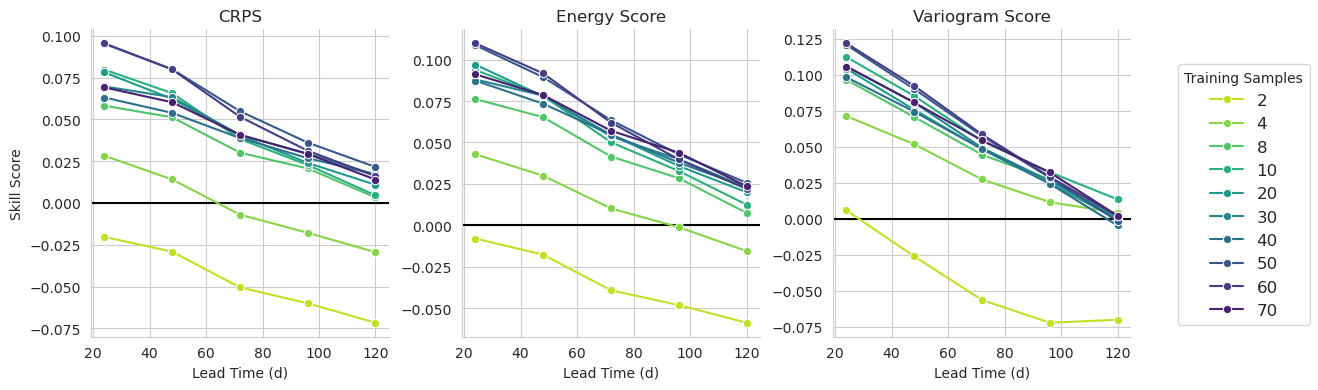

In [15]:
sns.set_style("whitegrid")

g = sns.FacetGrid(
    df.filter(pl.col("split").eq("test") & pl.col("variable").eq("combined")),
    col="score",
    height=4,
    aspect=1,
    sharex=True,
    sharey=False,
    margin_titles=True,
)

# Plot lines for each model+method
g.map_dataframe(
    sns.lineplot,
    x="Lead Time (d)",
    y="Skill Score",
    hue="n_samples_train",
    palette="viridis_r",
    marker="o",
    linewidth=1.5,
)

for ax in g.axes.flat:
    ax.axhline(0, color="black", linewidth=1.5, zorder=1)
    # ax.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))
    ax.set_xlabel("Lead Time (d)")
    ax.set_title(ax.get_title().replace("score = ", ""))
    if ax.get_ylabel() != "":
        ax.set_ylabel("Skill Score")

g.add_legend(frameon=True, title="Training Samples", title_fontsize=14, fontsize=12)
g.savefig(
    RESULTS_DIR / "results" / "wb2" / "ablations" / "n_samples_skill_score_leadtime.pdf",
    bbox_inches="tight",
)

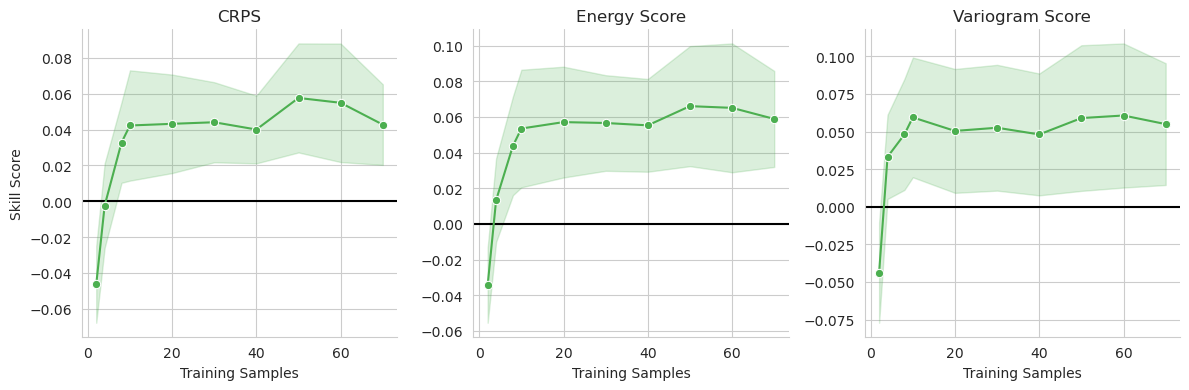

In [ ]:
color = "#4CAF50"

g = sns.FacetGrid(
    df.filter(pl.col("split").eq("test") & pl.col("variable").eq("combined")).with_columns(
        pl.col("n_samples_train").cast(pl.String).cast(pl.Int32)
    ),
    col="score",
    height=4,
    aspect=1,
    sharex=True,
    sharey=False,
    margin_titles=True,
)

# Plot lines for each model+method
g.map_dataframe(
    sns.lineplot,
    x="n_samples_train",
    y="Skill Score",
    color=color,
    marker="o",
    linewidth=1.5,
    errorbar="sd",
)

for ax in g.axes.flat:
    ax.axhline(0, color="black", linewidth=1.5, zorder=1)
    # ax.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))
    ax.set_xlabel("Training Samples")
    ax.set_title(ax.get_title().replace("score = ", ""))
    if ax.get_ylabel() != "":
        ax.set_ylabel("Skill Score")
g.savefig(
    RESULTS_DIR / "results" / "wb2" / "ablations" / "n_samples_skill_score.pdf", bbox_inches="tight"
)